In [22]:
import pandas as pd
import torch
import kagglehub
from transformers import pipeline
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# check specs of my computer to see if I can run sentiment analysis locally

In [2]:
print(torch.cuda.is_available())        # should be True
print(torch.cuda.get_device_name(0))    # should show RTX 3050

True
NVIDIA GeForce RTX 3050 Laptop GPU


# download dataset

In [3]:
# Download latest version
#path = kagglehub.dataset_download("dyutidasmahaptra/s-and-p-500-with-financial-news-headlines-20082024")

#print("Path to dataset files:", path)

In [4]:
news = pd.read_csv("data/financial_news.csv")
print(news.shape)
print(news.dtypes)
print(news.head())

(19127, 3)
Title     object
Date      object
CP       float64
dtype: object
                                               Title        Date       CP
0   JPMorgan Predicts 2008 Will Be "Nothing But Net"  2008-01-02  1447.16
1  Dow Tallies Biggest First-session-of-year Poin...  2008-01-02  1447.16
2                   2008 predictions for the S&P 500  2008-01-02  1447.16
3  U.S. Stocks Higher After Economic Data, Monsan...  2008-01-03  1447.16
4  U.S. Stocks Climb As Hopes Increase For More F...  2008-01-07  1416.18


# clean and resize to 2010

In [5]:
news["Date"] = pd.to_datetime(news["Date"])

# Filter to your analysis window
news = news[news["Date"] >= "2010-01-01"].copy()

# Drop any rows with missing headlines
news = news.dropna(subset=["Title"])

print(f"Rows after filtering: {len(news)}")
print(f"Date range: {news['Date'].min()} to {news['Date'].max()}")
print(f"Unique trading days: {news['Date'].nunique()}")

Rows after filtering: 18873
Date range: 2010-01-05 00:00:00 to 2024-03-04 00:00:00
Unique trading days: 3311


# test finBERT

In [6]:
# Load FinBERT on GPU
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    device=0,          # 0 = first GPU (your RTX 3050)
    truncation=True,
    max_length=512
)

# Quick sanity check
test = sentiment_pipeline([
    "Stock market crashes amid recession fears",
    "S&P 500 hits record high on strong earnings"
])
print(test)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 240.86it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'negative', 'score': 0.9367181658744812}, {'label': 'positive', 'score': 0.8646823167800903}]


# Run FinBERT on the whole financial news dataset and convert the score so that it goes from -1, extremely negative sentiment to +1, extremely positive sentiment

In [7]:
# headlines = news["Title"].tolist()
# batch_size = 64

# results = []
# for i in tqdm(range(0, len(headlines), batch_size)):
#     batch = headlines[i:i + batch_size]
#     output = sentiment_pipeline(batch)
#     results.extend(output)


# news["sentiment_label"] = [r["label"] for r in results]
# news["sentiment_score"]  = [r["score"]  for r in results]

# def signed_score(row):
#     if row["sentiment_label"] == "positive":
#         return row["sentiment_score"]
#     elif row["sentiment_label"] == "negative":
#         return -row["sentiment_score"]
#     else:
#         return 0.0

# news["signed_score"] = news.apply(signed_score, axis=1)

# # Save to file — never rerun FinBERT again
# news.to_csv("data/financial_news_sentiment.csv", index=False)

# print(f"Saved {len(news)} rows to data/financial_news_sentiment.csv")
# print(f"\nSentiment distribution:\n{news['sentiment_label'].value_counts()}")

In [8]:
# load from file is less wastefull
news = pd.read_csv("data/financial_news_sentiment.csv", parse_dates=["Date"])

# daily sentiment aggregation (because n headlines per day)

daily_sentiment = (
    news.groupby("Date")
    .agg(
        mean_signed_score  = ("signed_score", "mean"),
        n_headlines        = ("signed_score", "count"),
        pct_positive       = ("sentiment_label", lambda x: (x == "positive").mean()),
        pct_negative       = ("sentiment_label", lambda x: (x == "negative").mean()),
        pct_neutral        = ("sentiment_label", lambda x: (x == "neutral").mean()),
    )
    .reset_index()
)

# Save daily sentiment
daily_sentiment.to_csv("data/daily_sentiment.csv", index=False)

print(f"Daily sentiment shape: {daily_sentiment.shape}")
print(f"Date range: {daily_sentiment['Date'].min()} to {daily_sentiment['Date'].max()}")
display(daily_sentiment.head(10))

Daily sentiment shape: (3311, 6)
Date range: 2010-01-05 00:00:00 to 2024-03-04 00:00:00


,Date,mean_signed_score,n_headlines,pct_positive,pct_negative,pct_neutral
0,2010-01-05,-0.271520,3,0.0,0.333333,0.666667
1,2010-01-06,-0.505241,1,0.0,1.000000,0.000000
2,2010-01-07,0.000000,1,0.0,0.000000,1.000000
3,2010-01-11,0.000000,1,0.0,0.000000,1.000000
4,2010-01-13,-0.482075,2,0.0,0.500000,0.500000
5,2010-01-14,0.000000,1,0.0,0.000000,1.000000
6,2010-01-20,0.000000,1,0.0,0.000000,1.000000
7,2010-01-28,0.000000,2,0.0,0.000000,1.000000
8,2010-02-02,0.000000,1,0.0,0.000000,1.000000
9,2010-02-04,0.000000,1,0.0,0.000000,1.000000


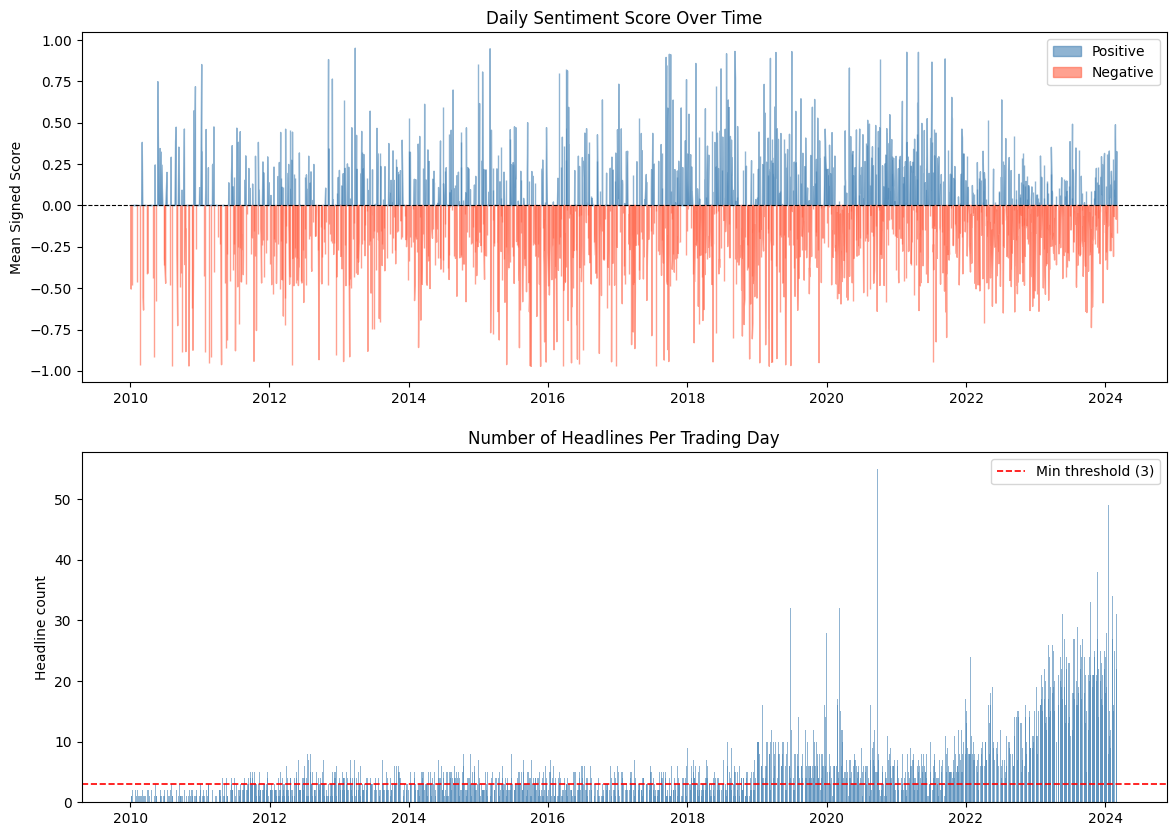

In [9]:
# make a plot to check the dataset because it seems sparse

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily sentiment score over time
axes[0].fill_between(
    daily_sentiment["Date"],
    daily_sentiment["mean_signed_score"],
    0,
    where=daily_sentiment["mean_signed_score"] >= 0,
    color="steelblue", alpha=0.6, label="Positive"
)
axes[0].fill_between(
    daily_sentiment["Date"],
    daily_sentiment["mean_signed_score"],
    0,
    where=daily_sentiment["mean_signed_score"] < 0,
    color="tomato", alpha=0.6, label="Negative"
)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Daily Sentiment Score Over Time")
axes[0].set_ylabel("Mean Signed Score")
axes[0].legend()

# Number of headlines per day

axes[1].bar(
    daily_sentiment["Date"],
    daily_sentiment["n_headlines"],
    color="steelblue", alpha=0.6, width=2
)
axes[1].axhline(3, color="red", linewidth=1.2, linestyle="--", label="Min threshold (3)")
axes[1].set_title("Number of Headlines Per Trading Day")
axes[1].set_ylabel("Headline count")
axes[1].legend()

# reload the other dataset

In [10]:
# -----------------------------
# 1. FF3 factors + momentum
# -----------------------------
ff3 = pd.read_csv("data/ff3_daily.csv", parse_dates=["Date"], index_col="Date")
ff3 = ff3 / 100
ff3 = ff3.rename(columns={"Mkt-RF": "mkt_rf", "SMB": "smb", "HML": "hml", "RF": "rf_ff"})

mom = pd.read_csv("data/momentum_daily.csv", parse_dates=["Date"], index_col="Date")
mom = mom / 100
mom = mom.rename(columns={"Mom": "umd"})

# -----------------------------
# 2. Stock returns
# -----------------------------
df = pd.read_csv("data/sp500_data_from_2010.csv", parse_dates=["Date"])
stocks = (
    df[df["Ticker"] != "^GSPC"][["Date", "Ticker", "Adj Close"]]
    .sort_values(["Ticker", "Date"])
)
stocks["stock_return"] = stocks.groupby("Ticker")["Adj Close"].pct_change()
stocks = stocks.dropna(subset=["stock_return"])

# -----------------------------
# 3. Extremes
# -----------------------------
extremes = pd.read_csv("data/sp500_pct_extremes.csv")
extremes["Date"] = pd.to_datetime(extremes["Date"])

# -----------------------------
# 4. Daily sentiment
# -----------------------------
daily_sentiment = pd.read_csv("data/daily_sentiment.csv", parse_dates=["Date"])

print("All data loaded.")
print(f"Stocks        : {stocks.shape}")
print(f"FF3 factors   : {ff3.shape}")
print(f"Momentum      : {mom.shape}")
print(f"Extremes      : {extremes.shape}")
print(f"Sentiment     : {daily_sentiment.shape}")

All data loaded.
Stocks        : (1732607, 4)
FF3 factors   : (4085, 4)
Momentum      : (4085, 1)
Extremes      : (1711, 17)
Sentiment     : (3311, 6)


In [11]:
# -----------------------------
# 5. Build full Carhart + Sentiment dataset
# -----------------------------
full_data = (
    stocks
    .merge(ff3[["mkt_rf", "smb", "hml", "rf_ff"]], left_on="Date", right_index=True, how="inner")
    .merge(mom[["umd"]], left_on="Date", right_index=True, how="inner")
    .merge(daily_sentiment[["Date", "mean_signed_score", "n_headlines"]], on="Date", how="left")
)

full_data["stock_excess"] = full_data["stock_return"] - full_data["rf_ff"]

print(f"Full dataset shape : {full_data.shape}")
display(full_data[["Date", "Ticker", "stock_excess", "mkt_rf", "smb", "hml", "umd", "mean_signed_score"]].head())

Full dataset shape : (1727531, 12)


,Date,Ticker,stock_excess,mkt_rf,smb,hml,umd,mean_signed_score
0,2010-01-05,A,-0.010863,0.0031,-0.0064,0.0122,0.0062,-0.271520
1,2010-01-06,A,-0.003553,0.0013,-0.0023,0.0055,-0.0005,-0.505241
2,2010-01-07,A,-0.001296,0.0040,0.0009,0.0096,-0.0087,0.000000
3,2010-01-08,A,-0.000325,0.0033,0.0036,0.0002,0.0020,NaN
4,2010-01-11,A,0.000649,0.0013,-0.0013,-0.0026,-0.0048,0.000000


In [12]:
# drop NaN sentiment days
full_data_sentiment = full_data.dropna(subset=["mean_signed_score"]).copy()

print(f"Full dataset          : {full_data.shape}")
print(f"With sentiment        : {full_data_sentiment.shape}")
print(f"Coverage              : {len(full_data_sentiment)/len(full_data)*100:.1f}%")

# Check date range
print(f"Date range            : {full_data_sentiment['Date'].min()} to {full_data_sentiment['Date'].max()}")

Full dataset          : (1727531, 12)
With sentiment        : (1400553, 12)
Coverage              : 81.1%
Date range            : 2010-01-05 00:00:00 to 2024-03-04 00:00:00


# run the regressions

In [13]:
# -----------------------------
# 1. Sentiment regression loop
# -----------------------------
def run_sentiment_loop(df, label, min_obs=5):
    results = []
    for ticker, group in df.groupby("Ticker"):
        if len(group) < min_obs:
            continue
        try:
            X = sm.add_constant(group[["mkt_rf", "smb", "hml", "umd", "mean_signed_score"]])
            y = group["stock_excess"]
            model = sm.OLS(y, X).fit()
            results.append({
                "Ticker":           ticker,
                "alpha":            model.params["const"],
                "beta_mkt":         model.params["mkt_rf"],
                "beta_smb":         model.params["smb"],
                "beta_hml":         model.params["hml"],
                "beta_umd":         model.params["umd"],
                "beta_sentiment":   model.params["mean_signed_score"],
                "r2":               model.rsquared,
                "adj_r2":           model.rsquared_adj,
                "p_alpha":          model.pvalues["const"],
                "p_beta_mkt":       model.pvalues["mkt_rf"],
                "p_beta_smb":       model.pvalues["smb"],
                "p_beta_hml":       model.pvalues["hml"],
                "p_beta_umd":       model.pvalues["umd"],
                "p_beta_sentiment": model.pvalues["mean_signed_score"],
                "n":                len(group)
            })
        except Exception:
            continue
    return pd.DataFrame(results)

# -----------------------------
# 2. Run full sample
# -----------------------------
sentiment_full = run_sentiment_loop(full_data_sentiment, "Sentiment — Full Sample")

# -----------------------------
# 3. Merge and split extremes
# -----------------------------
sentiment_extremes = extremes.merge(
    full_data_sentiment[["Date", "Ticker", "stock_excess", "mkt_rf", "smb", "hml", "umd", "mean_signed_score"]],
    on=["Date", "Ticker"],
    how="inner"
)
sentiment_pos = sentiment_extremes[sentiment_extremes["stock_excess"] > 0].copy()
sentiment_neg = sentiment_extremes[sentiment_extremes["stock_excess"] < 0].copy()

print(f"Extreme obs with sentiment : {len(sentiment_extremes)}")
print(f"Positive tail              : {len(sentiment_pos)}")
print(f"Negative tail              : {len(sentiment_neg)}")

# -----------------------------
# 4. Run tail regressions
# -----------------------------
sentiment_tail_pos = run_sentiment_loop(sentiment_pos, "Sentiment — Positive Tail")
sentiment_tail_neg = run_sentiment_loop(sentiment_neg, "Sentiment — Negative Tail")

print(f"\nFull sample   : {len(sentiment_full)}")
print(f"Positive tail : {len(sentiment_tail_pos)}")
print(f"Negative tail : {len(sentiment_tail_neg)}")

Extreme obs with sentiment : 1365
Positive tail              : 539
Negative tail              : 826


/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/


Full sample   : 423
Positive tail : 32
Negative tail : 47


/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/pierre/Documents/CFDS-1/venv/lib/python3.12/site-packages/

In [14]:
# -----------------------------
# 5. Summary and comparison
# -----------------------------
def summarize_sentiment(df, label):
    return {
        "sample":               label,
        "n_stocks":             len(df),
        "median_r2":            df["r2"].median(),
        "median_adj_r2":        df["adj_r2"].median(),
        "median_beta_mkt":      df["beta_mkt"].median(),
        "median_beta_smb":  df["beta_smb"].median(),
        "median_beta_hml":  df["beta_hml"].median(),
        "median_beta_umd":      df["beta_umd"].median(),
        "median_beta_sentiment":df["beta_sentiment"].median(),
        "median_alpha_ann":     (df["alpha"] * 252).median(),
        "pct_sig_alpha":        (df["p_alpha"] < 0.05).mean() * 100,
        "pct_sig_sentiment":    (df["p_beta_sentiment"] < 0.05).mean() * 100,
    }

comparison = pd.DataFrame([
    summarize_sentiment(sentiment_full,     "Sentiment — Full Sample"),
    summarize_sentiment(sentiment_tail_pos, "Sentiment — Positive Tail"),
    summarize_sentiment(sentiment_tail_neg, "Sentiment — Negative Tail"),
])

display(comparison.T)

,0,1,2
sample,Sentiment — Full Sample,Sentiment — Positive Tail,Sentiment — Negative Tail
n_stocks,423,32,47
median_r2,0.413318,0.904962,1.0
median_adj_r2,0.41243,0.259324,0.291162
median_beta_mkt,0.964401,-0.066094,0.087291
median_beta_smb,0.040218,-0.162851,1.164095
median_beta_hml,0.171875,-0.640028,0.197366
median_beta_umd,-0.00604,-0.3372,0.993179
median_beta_sentiment,-0.000361,-0.042487,-0.012072
median_alpha_ann,0.032603,46.67703,-38.152934


In [21]:
sentiment_matrix = sentiment_full[['alpha','beta_mkt','beta_smb','beta_hml','beta_umd','beta_sentiment']]
corr_matrix = sentiment_matrix.corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

,alpha,beta_mkt,beta_smb,beta_hml,beta_umd,beta_sentiment
alpha,1.000000,0.092686,0.290206,-0.394858,0.425370,0.127724
beta_mkt,0.092686,1.000000,0.600818,0.152756,-0.415668,0.174555
beta_smb,0.290206,0.600818,1.000000,0.106909,-0.331364,0.277959
beta_hml,-0.394858,0.152756,0.106909,1.000000,-0.449070,0.057881
beta_umd,0.425370,-0.415668,-0.331364,-0.449070,1.000000,-0.341020
beta_sentiment,0.127724,0.174555,0.277959,0.057881,-0.341020,1.000000


In [23]:
X = sentiment_full[
    ['beta_mkt','beta_smb','beta_hml','beta_umd','beta_sentiment']
]

X = add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

         variable        VIF
0           const  26.551017
1        beta_mkt   1.716323
2        beta_smb   1.648690
3        beta_hml   1.270870
4        beta_umd   1.650762
5  beta_sentiment   1.192624


In [15]:
final_comparison = pd.DataFrame([
    {"Model": "CAPM",      "Adj R² pos": "~0.05", "Adj R² neg": "~0.08", "% sig α pos": 100,  "% sig α neg": 95},
    {"Model": "FF3",       "Adj R² pos": 0.073,   "Adj R² neg": 0.157,   "% sig α pos": 86,   "% sig α neg": 75},
    {"Model": "Carhart",   "Adj R² pos": 0.138,   "Adj R² neg": 0.289,   "% sig α pos": 50,   "% sig α neg": 62},
    {"Model": "Sentiment", "Adj R² pos": 0.259,   "Adj R² neg": 0.291,   "% sig α pos": 31.25,"% sig α neg": 27.7},
])
print(final_comparison.to_string(index=False))

    Model Adj R² pos Adj R² neg  % sig α pos  % sig α neg
     CAPM      ~0.05      ~0.08       100.00         95.0
      FF3      0.073      0.157        86.00         75.0
  Carhart      0.138      0.289        50.00         62.0
Sentiment      0.259      0.291        31.25         27.7


In [ ]:
# CAPM whole set median adjusted r-squared 0.34
# CAPM positive tail median adjusted r-squared 0.09
# CAPM negative tail median adjusted r-squared 0.13

# FF3 whole set median adjusted r-squared 0.37
# FF3 positive tail median adjusted r-squared 0.07
# FF3 negative tail median adjusted r-squared 0.15

# MOM whole set median adjusted r-squared 0.37
# MOM positive tail median adjusted r-squared 0.14
# MOM negative tail median adjusted r-squared 0.29

# Sentiment whole set median adjusted r-squared 0.41
# Sentiment positive tail median adjusted r-squared 0.25
# Sentiment negative tail median adjusted r-squared 0.29

In [24]:
summary_df = pd.DataFrame({
    'Model': ['CAPM', 'FF3', 'MOM', 'Sentiment'],
    'Whole Set Median Adj R²': [0.34, 0.37, 0.37, 0.41],
    'Positive Tail Median Adj R²': [0.09, 0.07, 0.14, 0.25],
    'Negative Tail Median Adj R²': [0.13, 0.15, 0.29, 0.29]
})

display(summary_df)

,Model,Whole Set Median Adj R²,Positive Tail Median Adj R²,Negative Tail Median Adj R²
0,CAPM,0.34,0.09,0.13
1,FF3,0.37,0.07,0.15
2,MOM,0.37,0.14,0.29
3,Sentiment,0.41,0.25,0.29
